# Language Translation Analysis: English → Spanish with GPT-4o

This notebook analyzes token count changes when translating medical text from English to Spanish using OpenAI's GPT-4o model with the o200k_base tokenizer.

**Goal**: Understand and quantify the token increase phenomenon across different sentence complexities and batches.

In [1]:
import xml.etree.ElementTree as ET
import os
from getpass import getpass
from openai import OpenAI
import json
import tiktoken

# Initialize OpenAI client.
# If OPENAI_API_KEY is not available in this notebook kernel, prompt once.
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    api_key = getpass("Enter OPENAI_API_KEY: ").strip()

client = OpenAI(api_key=api_key)

# Initialize tokenizer for GPT-4o (o200k_base)
encoding = tiktoken.get_encoding("o200k_base")

In [2]:
def extract_questions(folder_path, max_q=30):
    """Extract questions from MedQuAD XML files"""
    questions = []
    for root_dir, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".xml"):
                try:
                    tree = ET.parse(os.path.join(root_dir, file))
                    root = tree.getroot()
                    for qa in root.findall(".//QAPair"):
                        q = qa.find("Question")
                        if q is not None and q.text:
                            questions.append(q.text)
                        if len(questions) >= max_q:
                            return questions
                except:
                    pass
    return questions

def add_clinical_sentences():
    """Add realistic clinical-style sentences"""
    return [
        "The patient presented with acute myocardial infarction and elevated troponin levels.",
        "Magnetic resonance imaging revealed a herniated intervertebral disc at L4-L5.",
        "The hematology panel indicated microcytic anemia with hemoglobin of 7.2 g/dL.",
        "Renal function tests showed creatinine of 2.5 mg/dL with estimated GFR of 28.",
        "The chest X-ray demonstrated bilateral pneumonia with consolidation in both lower lobes.",
    ]

def classify_complexity(sentence):
    """Classify sentence as simple (<50 chars) or complex (>=50 chars)"""
    return "simple" if len(sentence) < 50 else "complex"

def count_tokens_for_text(text):
    """Count tokens using o200k_base encoding"""
    return len(encoding.encode(text))

In [3]:
def translate_and_count_tokens(sentences, batch_size=10):
    """Translate sentences to Spanish in batches and analyze token changes"""
    all_results = []
    batch_stats = []
    
    for batch_num, i in enumerate(range(0, len(sentences), batch_size), 1):
        batch = sentences[i:i+batch_size]
        text_to_translate = "\n".join(batch)
        
        # Count tokens for English sentences (per-sentence + total)
        english_tokens_per_sentence = [count_tokens_for_text(s) for s in batch]
        english_tokens_total = sum(english_tokens_per_sentence)
        
        # Translate using GPT-4o
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {
                    "role": "system",
                    "content": "Translate the following English text to Spanish. Maintain medical terminology accuracy."
                },
                {
                    "role": "user",
                    "content": text_to_translate
                }
            ]
        )
        
        spanish_text = response.choices[0].message.content
        spanish_sentences = spanish_text.split("\n")
        
        # Count tokens for Spanish sentences (per-sentence + total)
        spanish_tokens_per_sentence = [count_tokens_for_text(s) for s in spanish_sentences if s.strip()]
        spanish_tokens_total = sum(spanish_tokens_per_sentence)
        
        # Per-sentence analysis
        batch_results = []
        for j, (en_sent, es_sent) in enumerate(zip(batch, spanish_sentences)):
            if j < len(spanish_tokens_per_sentence):
                en_tokens = english_tokens_per_sentence[j]
                es_tokens = spanish_tokens_per_sentence[j]
                token_change = es_tokens - en_tokens
                pct_change = (token_change / en_tokens * 100) if en_tokens > 0 else 0
                
                batch_results.append({
                    "sentence_num": i + j + 1,
                    "batch": batch_num,
                    "english_text": en_sent,
                    "spanish_text": es_sent.strip(),
                    "complexity": classify_complexity(en_sent),
                    "english_tokens": en_tokens,
                    "spanish_tokens": es_tokens,
                    "token_change": token_change,
                    "pct_change": round(pct_change, 2)
                })
        
        # Batch statistics
        ratio = spanish_tokens_total / english_tokens_total if english_tokens_total > 0 else 0
        batch_stat = {
            "batch": batch_num,
            "sentence_count": len(batch),
            "english_tokens_total": english_tokens_total,
            "spanish_tokens_total": spanish_tokens_total,
            "token_change": spanish_tokens_total - english_tokens_total,
            "ratio": round(ratio, 3),
            "pct_change": round((spanish_tokens_total - english_tokens_total) / english_tokens_total * 100, 2)
        }
        
        batch_stats.append(batch_stat)
        all_results.extend(batch_results)
        
        print(f"Batch {batch_num}: EN={english_tokens_total} → ES={spanish_tokens_total} (ratio: {ratio:.3f}, {batch_stat['pct_change']:+.1f}%)")
    
    return all_results, batch_stats

In [4]:
# Extract questions (30 samples for trial)
print("Extracting questions from MedQuAD...")
questions = extract_questions("Dataset_MedQuAD", max_q=30)
print(f"Extracted {len(questions)} questions")

# Add clinical sentences
print("\nAdding clinical sentences...")
clinical = add_clinical_sentences()
all_sentences = questions + clinical
print(f"Total sentences: {len(all_sentences)}")

# Translate and track tokens (batch size = 10)
print("\nTranslating to Spanish in batches of 10 (tracking tokens)...")
print("="*70)
results, batch_stats = translate_and_count_tokens(all_sentences, batch_size=10)

Extracting questions from MedQuAD...
Extracted 30 questions

Adding clinical sentences...
Total sentences: 35

Translating to Spanish in batches of 10 (tracking tokens)...
Batch 1: EN=137 → ES=165 (ratio: 1.204, +20.4%)
Batch 2: EN=96 → ES=129 (ratio: 1.344, +34.4%)
Batch 3: EN=92 → ES=122 (ratio: 1.326, +32.6%)
Batch 4: EN=93 → ES=116 (ratio: 1.247, +24.7%)


In [5]:
# ===== BATCH CONSISTENCY ANALYSIS =====
print("\n" + "="*70)
print("BATCH CONSISTENCY ANALYSIS")
print("="*70)
for stat in batch_stats:
    print(f"Batch {stat['batch']}: {stat['sentence_count']} sentences | "
          f"EN={stat['english_tokens_total']} → ES={stat['spanish_tokens_total']} | "
          f"Ratio: {stat['ratio']:.3f} | Change: {stat['pct_change']:+.1f}%")


BATCH CONSISTENCY ANALYSIS
Batch 1: 10 sentences | EN=137 → ES=165 | Ratio: 1.204 | Change: +20.4%
Batch 2: 10 sentences | EN=96 → ES=129 | Ratio: 1.344 | Change: +34.4%
Batch 3: 10 sentences | EN=92 → ES=122 | Ratio: 1.326 | Change: +32.6%
Batch 4: 5 sentences | EN=93 → ES=116 | Ratio: 1.247 | Change: +24.7%


In [6]:
# ===== OVERALL STATISTICS =====
total_en = sum(r["english_tokens"] for r in results)
total_es = sum(r["spanish_tokens"] for r in results)
overall_ratio = total_es / total_en if total_en > 0 else 0
overall_pct = (total_es - total_en) / total_en * 100

print("\n" + "="*70)
print("OVERALL STATISTICS")
print("="*70)
print(f"Total English Tokens: {total_en}")
print(f"Total Spanish Tokens: {total_es}")
print(f"Total Token Change: {total_es - total_en:+d}")
print(f"Overall Ratio (ES/EN): {overall_ratio:.3f}")
print(f"Percentage Change: {overall_pct:+.2f}%")


OVERALL STATISTICS
Total English Tokens: 340
Total Spanish Tokens: 532
Total Token Change: +192
Overall Ratio (ES/EN): 1.565
Percentage Change: +56.47%


In [7]:
# ===== COMPLEXITY ANALYSIS =====
simple = [r for r in results if r["complexity"] == "simple"]
complex_sent = [r for r in results if r["complexity"] == "complex"]

print("\n" + "="*70)
print("COMPLEXITY ANALYSIS")
print("="*70)
print(f"\nSimple sentences ({len(simple)} total):")
if simple:
    simple_en = sum(r["english_tokens"] for r in simple)
    simple_es = sum(r["spanish_tokens"] for r in simple)
    simple_ratio = simple_es / simple_en if simple_en > 0 else 0
    simple_pct = (simple_es - simple_en) / simple_en * 100
    print(f"  EN={simple_en} → ES={simple_es} | Ratio: {simple_ratio:.3f} | Change: {simple_pct:+.2f}%")
    print(f"  Avg token change per sentence: {sum(r['token_change'] for r in simple) / len(simple):+.1f}")

print(f"\nComplex sentences ({len(complex_sent)} total):")
if complex_sent:
    complex_en = sum(r["english_tokens"] for r in complex_sent)
    complex_es = sum(r["spanish_tokens"] for r in complex_sent)
    complex_ratio = complex_es / complex_en if complex_en > 0 else 0
    complex_pct = (complex_es - complex_en) / complex_en * 100
    print(f"  EN={complex_en} → ES={complex_es} | Ratio: {complex_ratio:.3f} | Change: {complex_pct:+.2f}%")
    print(f"  Avg token change per sentence: {sum(r['token_change'] for r in complex_sent) / len(complex_sent):+.1f}")


COMPLEXITY ANALYSIS

Simple sentences (22 total):
  EN=202 → ES=262 | Ratio: 1.297 | Change: +29.70%
  Avg token change per sentence: +2.7

Complex sentences (9 total):
  EN=138 → ES=270 | Ratio: 1.957 | Change: +95.65%
  Avg token change per sentence: +14.7


In [8]:
# ===== PER-SENTENCE STATISTICS =====
token_changes = [r["token_change"] for r in results]
pct_changes = [r["pct_change"] for r in results]

increases = [r for r in results if r["token_change"] > 0]
decreases = [r for r in results if r["token_change"] < 0]
same = [r for r in results if r["token_change"] == 0]

print("\n" + "="*70)
print("PER-SENTENCE TOKEN CHANGE ANALYSIS")
print("="*70)
print(f"Sentences with token increase: {len(increases)} ({len(increases)/len(results)*100:.1f}%)")
print(f"Sentences with token decrease: {len(decreases)} ({len(decreases)/len(results)*100:.1f}%)")
print(f"Sentences with no change: {len(same)} ({len(same)/len(results)*100:.1f}%)")
print(f"\nAverage token change per sentence: {sum(token_changes) / len(token_changes):+.2f}")
print(f"Average percent change per sentence: {sum(pct_changes) / len(pct_changes):+.2f}%")
print(f"Max token increase: {max([r['token_change'] for r in increases], default=0)}")
print(f"Max token decrease: {min([r['token_change'] for r in decreases], default=0)}")


PER-SENTENCE TOKEN CHANGE ANALYSIS
Sentences with token increase: 28 (90.3%)
Sentences with token decrease: 2 (6.5%)
Sentences with no change: 1 (3.2%)

Average token change per sentence: +6.19
Average percent change per sentence: +50.21%
Max token increase: 101
Max token decrease: -1


In [9]:
# ===== SAVE RESULTS =====
output_data = {
    "summary": {
        "total_sentences": len(results),
        "total_english_tokens": total_en,
        "total_spanish_tokens": total_es,
        "overall_ratio": round(overall_ratio, 3),
        "overall_pct_change": round(overall_pct, 2)
    },
    "batch_stats": batch_stats,
    "complexity_analysis": {
        "simple": {
            "count": len(simple),
            "english_tokens": sum(r["english_tokens"] for r in simple),
            "spanish_tokens": sum(r["spanish_tokens"] for r in simple)
        },
        "complex": {
            "count": len(complex_sent),
            "english_tokens": sum(r["english_tokens"] for r in complex_sent),
            "spanish_tokens": sum(r["spanish_tokens"] for r in complex_sent)
        }
    },
    "per_sentence_results": results
}

with open("translation_results.json", "w") as f:
    json.dump(output_data, f, indent=2)
print("\n" + "="*70)
print("Results saved to translation_results.json")
print("="*70)


Results saved to translation_results.json


## Visual Analysis

### 1. Distribution of Per-Sentence Token Change

**Purpose**: To see if token change is consistently positive (increase) or if it's a mix of increases and decreases.

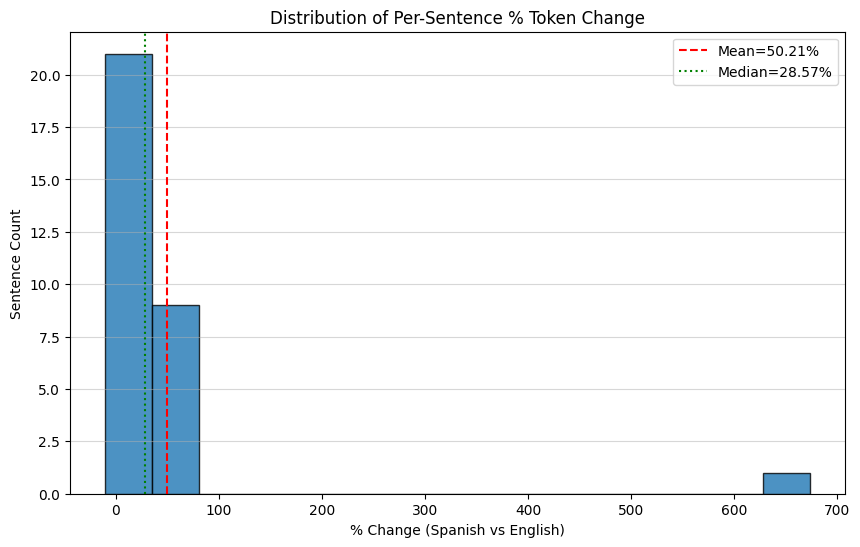

Percent-change distribution summary (per sentence):
count     31.000000
mean      50.205161
std      116.915515
min      -10.000000
10%       11.110000
25%       24.040000
50%       28.570000
75%       42.220000
90%       55.560000
max      673.330000
Name: pct_change, dtype: float64


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Build DataFrame from existing metrics
res_df = pd.DataFrame(results)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(res_df["pct_change"], bins=15, edgecolor="black", alpha=0.8)
plt.axvline(res_df["pct_change"].mean(), color="red", linestyle="--", label=f"Mean={res_df['pct_change'].mean():.2f}%")
plt.axvline(res_df["pct_change"].median(), color="green", linestyle=":", label=f"Median={res_df['pct_change'].median():.2f}%")
plt.title("Distribution of Per-Sentence % Token Change")
plt.xlabel("% Change (Spanish vs English)")
plt.ylabel("Sentence Count")
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

# Show descriptive stats
print("Percent-change distribution summary (per sentence):")
print(res_df["pct_change"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

### 2. Sentence Complexity vs. Token Change

**Purpose**: To determine if longer, more complex sentences have a different token increase pattern than shorter, simpler ones.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16184\4250019519.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([simple_vals, complex_vals], labels=["Simple", "Complex"], showmeans=True)


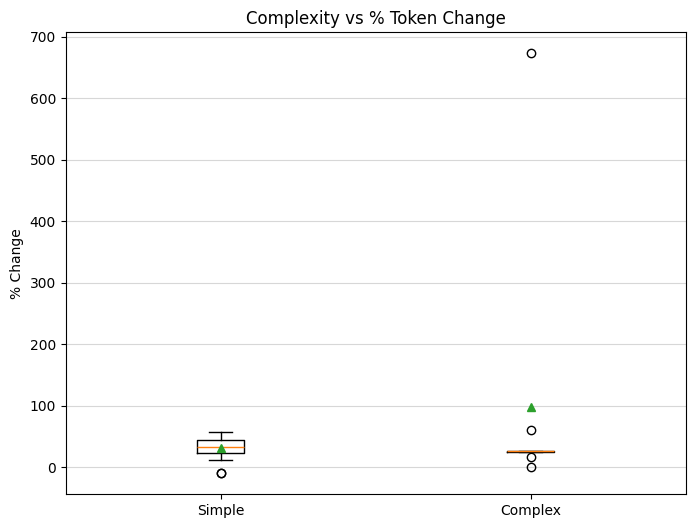

In [12]:
# Extract values for boxplot
simple_vals = res_df.loc[res_df["complexity"] == "simple", "pct_change"]
complex_vals = res_df.loc[res_df["complexity"] == "complex", "pct_change"]

plt.figure(figsize=(8, 6))
plt.boxplot([simple_vals, complex_vals], labels=["Simple", "Complex"], showmeans=True)
plt.title("Complexity vs % Token Change")
plt.ylabel("% Change")
plt.grid(axis='y', alpha=0.5)
plt.show()

### Plot Without Outliers

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16184\2167057548.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([simple_no_outliers['pct_change'], complex_no_outliers['pct_change']], labels=["Simple (No Outliers)", "Complex (No Outliers)"], showmeans=True)


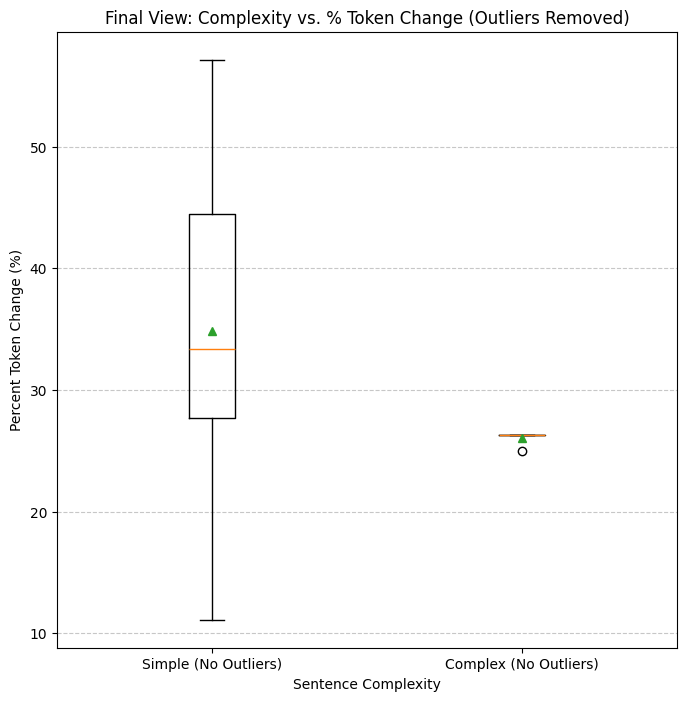

In [17]:
# Remove outliers from each category for a cleaner comparison
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

simple_no_outliers = remove_outliers(res_df[res_df['complexity'] == 'simple'], 'pct_change')
complex_no_outliers = remove_outliers(res_df[res_df['complexity'] == 'complex'], 'pct_change')

# Plot again with outliers removed
plt.figure(figsize=(8, 8))
plt.boxplot([simple_no_outliers['pct_change'], complex_no_outliers['pct_change']], labels=["Simple (No Outliers)", "Complex (No Outliers)"], showmeans=True)
plt.title('Final View: Complexity vs. % Token Change (Outliers Removed)')
plt.ylabel('Percent Token Change (%)')
plt.xlabel('Sentence Complexity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Outlier Identification

**Purpose**: To identify the specific sentences that are driving the extreme ends of the distribution.

In [16]:
# Show top outliers one by one
print("--- Top 5 Largest Increases ---")
for index, row in res_df.nlargest(5, "pct_change").iterrows():
    print(f"\n--- Example: {row['pct_change']:+.2f}% Change ---")
    print(f"Complexity: {row['complexity']}")
    print(f"EN ({row['english_tokens']} tokens): {row['english_text']}")
    print(f"ES ({row['spanish_tokens']} tokens): {row['spanish_text']}")
    print("-" * 20)

print("\n\n--- Top 5 Largest Decreases ---")
for index, row in res_df.nsmallest(5, "pct_change").iterrows():
    print(f"\n--- Example: {row['pct_change']:+.2f}% Change ---")
    print(f"Complexity: {row['complexity']}")
    print(f"EN ({row['english_tokens']} tokens): {row['english_text']}")
    print(f"ES ({row['spanish_tokens']} tokens): {row['spanish_text']}")
    print("-" * 20)

--- Top 5 Largest Increases ---

--- Example: +673.33% Change ---
Complexity: complex
EN (15 tokens): The patient presented with acute myocardial infarction and elevated troponin levels.
ES (116 tokens): El paciente presentó con un infarto agudo de miocardio y niveles elevados de troponina. La resonancia magnética reveló un disco intervertebral herniado en L4-L5. El panel de hematología indicó anemia microcítica con hemoglobina de 7.2 g/dL. Las pruebas de función renal mostraron creatinina de 2.5 mg/dL con un FGe estimado de 28. La radiografía de tórax demostró neumonía bilateral con consolidación en ambos lóbulos inferiores.
--------------------

--- Example: +60.00% Change ---
Complexity: complex
EN (10 tokens): Do you have information about A guide to herbal remedies
ES (16 tokens): ¿Tienes información sobre una guía de remedios a base de hierbas?
--------------------

--- Example: +57.14% Change ---
Complexity: simple
EN (7 tokens): How to diagnose Aase syndrome ?
ES (11 tokens): ¿